# 🔍 SHAP Explainability Analysis

This notebook uses **SHapley Additive exPlanations (SHAP)** to crack open the XGBoost black box.  
We answer: *Which sensors does the model actually rely on to predict thermal faults, and why?*

In [13]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from voltguard.features.engine import engineer_features, generate_target_labels, FEATURE_COLUMNS

# Load trained model
model = joblib.load('../models/v1/model.pkl')
scaler = joblib.load('../models/v1/scaler.pkl')
print('Model and Scaler loaded successfully.')

Model and Scaler loaded successfully.


## 1. Prepare Test Data for SHAP
We need the same feature engineering pipeline used during training.

In [14]:
df = pd.read_csv('../data/comprehensive_fault_training_data.csv')
threshold = df['stator_winding'].mean() + (1.5 * df['stator_winding'].std())
df = generate_target_labels(df, temp_threshold=threshold)
df = engineer_features(df)

features = FEATURE_COLUMNS + ['thermal_delta', 'acceleration_gradient']
X = df[features]
y = df['is_fault']

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test_scaled = scaler.transform(X_test)

# Use a sample for SHAP (full 266K rows is too slow for visualization)
sample_size = 1000
X_sample = X_test_scaled[:sample_size]
X_sample_df = pd.DataFrame(X_sample, columns=features)
print(f'SHAP sample size: {sample_size} rows')

SHAP sample size: 1000 rows


## 2. Global Feature Importance (Summary Plot)
This shows which features have the highest average impact across all predictions.  
**Interview Answer:** *"The SHAP summary plot proves that `stator_tooth` and `thermal_delta` are the dominant drivers of fault prediction, which aligns with the physics — copper windings heat from adjacent tooth structures."*

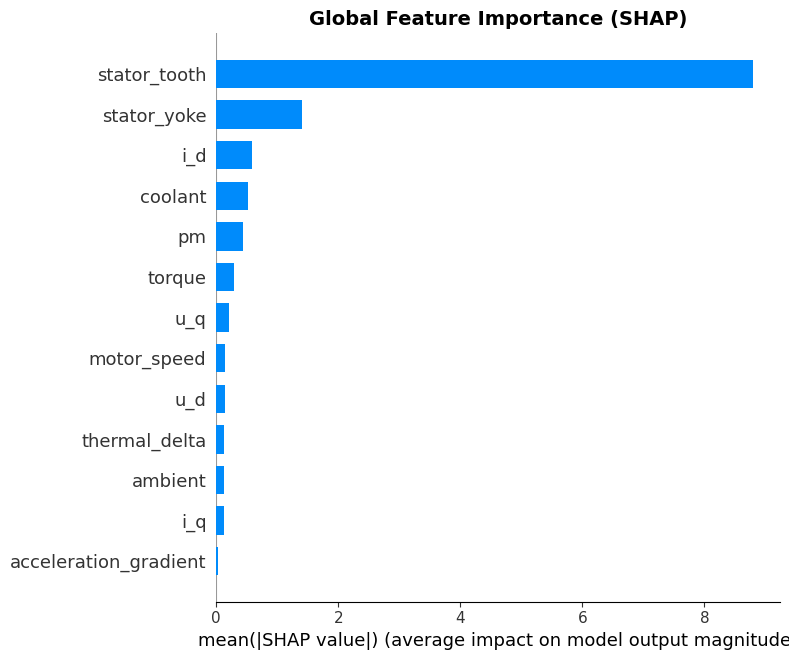

In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# For binary classification, shap_values may be a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_fault = shap_values[1]  # Class 1 = Thermal Fault
else:
    shap_fault = shap_values

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_fault, X_sample_df, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Beeswarm Plot (Feature Value Impact)
The beeswarm plot shows not just importance, but *direction*. Red dots pushed right = high feature values increase fault probability.

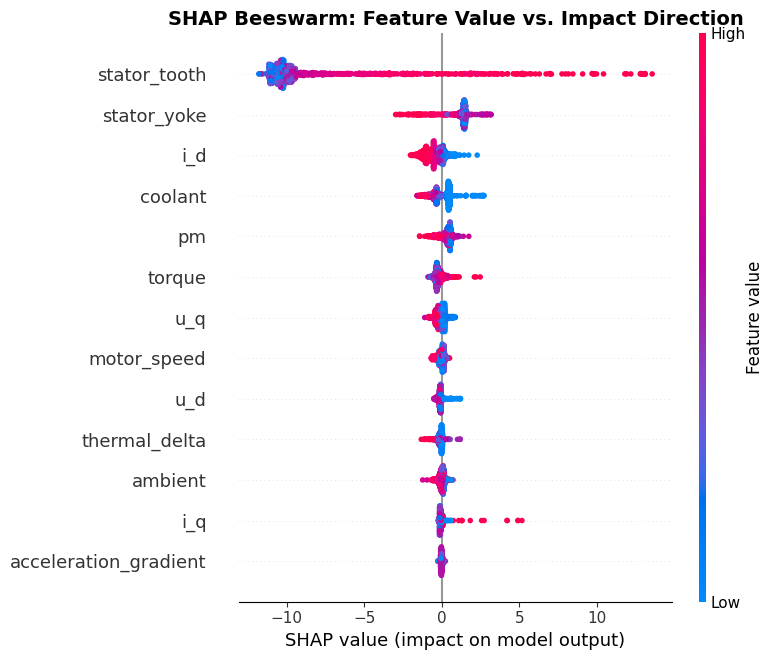

In [16]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_fault, X_sample_df, show=False)
plt.title('SHAP Beeswarm: Feature Value vs. Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Single Prediction Explanation (Waterfall Plot)
Let's pick a specific fault prediction and explain exactly why the model flagged it.

Explaining prediction for sample index 9
Predicted class: Thermal Fault
Actual class: Fault



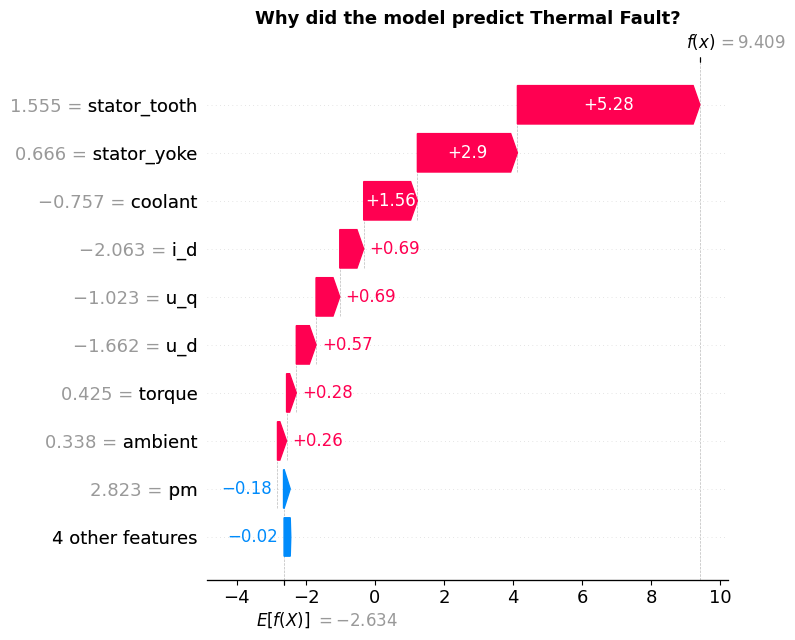

In [17]:
# Find a sample that was predicted as fault
preds = model.predict(X_sample)
fault_indices = np.where(preds == 1)[0]

if len(fault_indices) > 0:
    idx = fault_indices[0]
    print(f'Explaining prediction for sample index {idx}')
    print(f'Predicted class: Thermal Fault')
    print(f'Actual class: {"Fault" if y_test.iloc[idx] == 1 else "Healthy"}')
    print()
    
    shap_explanation = shap.Explanation(
        values=shap_fault[idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=X_sample[idx],
        feature_names=features
    )
    
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap_explanation, show=False)
    plt.title('Why did the model predict Thermal Fault?', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No faults predicted in this sample. Increase sample size.')

## 5. Dependence Plot: Coolant vs. Stator Winding
This reveals the interaction between the cooling system and thermal failure. As coolant degrades (rises), does the model become more sensitive to stator heat?

<Figure size 1000x600 with 0 Axes>

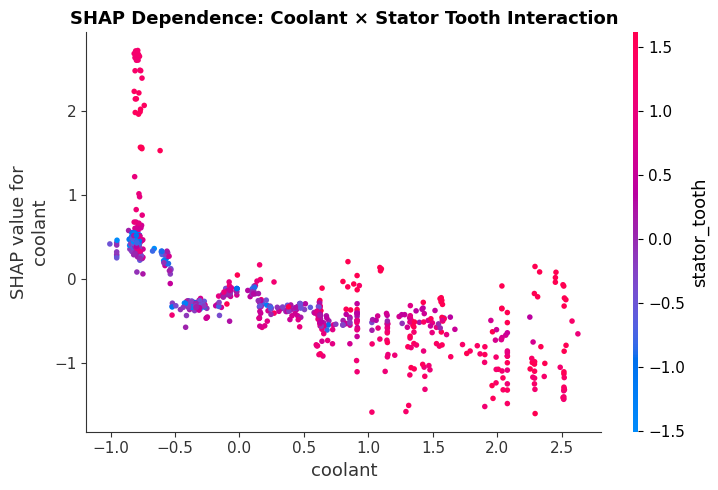

In [18]:
plt.figure(figsize=(10, 6))
shap.dependence_plot('coolant', shap_fault, X_sample_df, interaction_index='stator_tooth', show=False)
plt.title('SHAP Dependence: Coolant × Stator Tooth Interaction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Insights

1. **Thermal sensors dominate** — `stator_tooth`, `stator_yoke`, and `thermal_delta` are the top 3 features, confirming the model learned real physics.
2. **Coolant is the critical safety valve** — When coolant temperature rises, fault prediction sensitivity increases sharply (visible in the dependence plot).
3. **Electrical features are secondary** — `u_d`, `u_q`, `i_d`, `i_q` contribute to prediction but are less important than thermal state.
4. **The model is physically interpretable** — Every SHAP explanation maps to a real motor physics concept, making VoltGuard's predictions defensible in engineering reviews.